# 03 · Regular four-dimensional longitude, depth, and time connections
The logical input is `[lon,lat,depth,time]`. Ordinary 80-connectivity is followed by periodic longitude connections; latitude, depth, and time are not periodic.
This notebook presents manually interpretable four-dimensional cases and reruns comparisons with synthetic fixtures executed in MATLAB. Real production four-dimensional input has not been supplied.

In [1]:
include(isfile("bootstrap.jl") ? "bootstrap.jl" : "notebooks/bootstrap.jl")

  Activating 

Julia 1

project at `/Volumes/new_drive/lagrangian/julia/notebooks`


.12.3 | MHWTracking 0.1.0


## Longitude seams and depth/time diagonals
A and B differ by one step across the longitude seam, latitude, depth, and time, so they connect. C is two depth levels away from B and distant from A, so it remains separate.
In the three-dimensional view, z is a depth index, not depth in meters. Colors represent event labels, and point annotations show the local day.

(method

 = "regular_lonlat_4d_bwconncomp_periodic_lon_union", mask_size = (8, 6, 4, 4), grid_size = (8, 6, 4), ntime_local = 4, ntime_total = 4, min_duration = 1, connectivity = "full 3x3x3x3 within regular lon-lat grid; periodic lon seam union with dlat,dz,dt in -1:1", index_field = "idx4", has_idx5_alias = false, n_components_before_periodic_union = 3, n_raw_components = 2, n_tracks = 2, n_lon_seam_edges = 32, n_active_lon_boundary_cells = 3, n_lon_seam_component_pairs = 2)


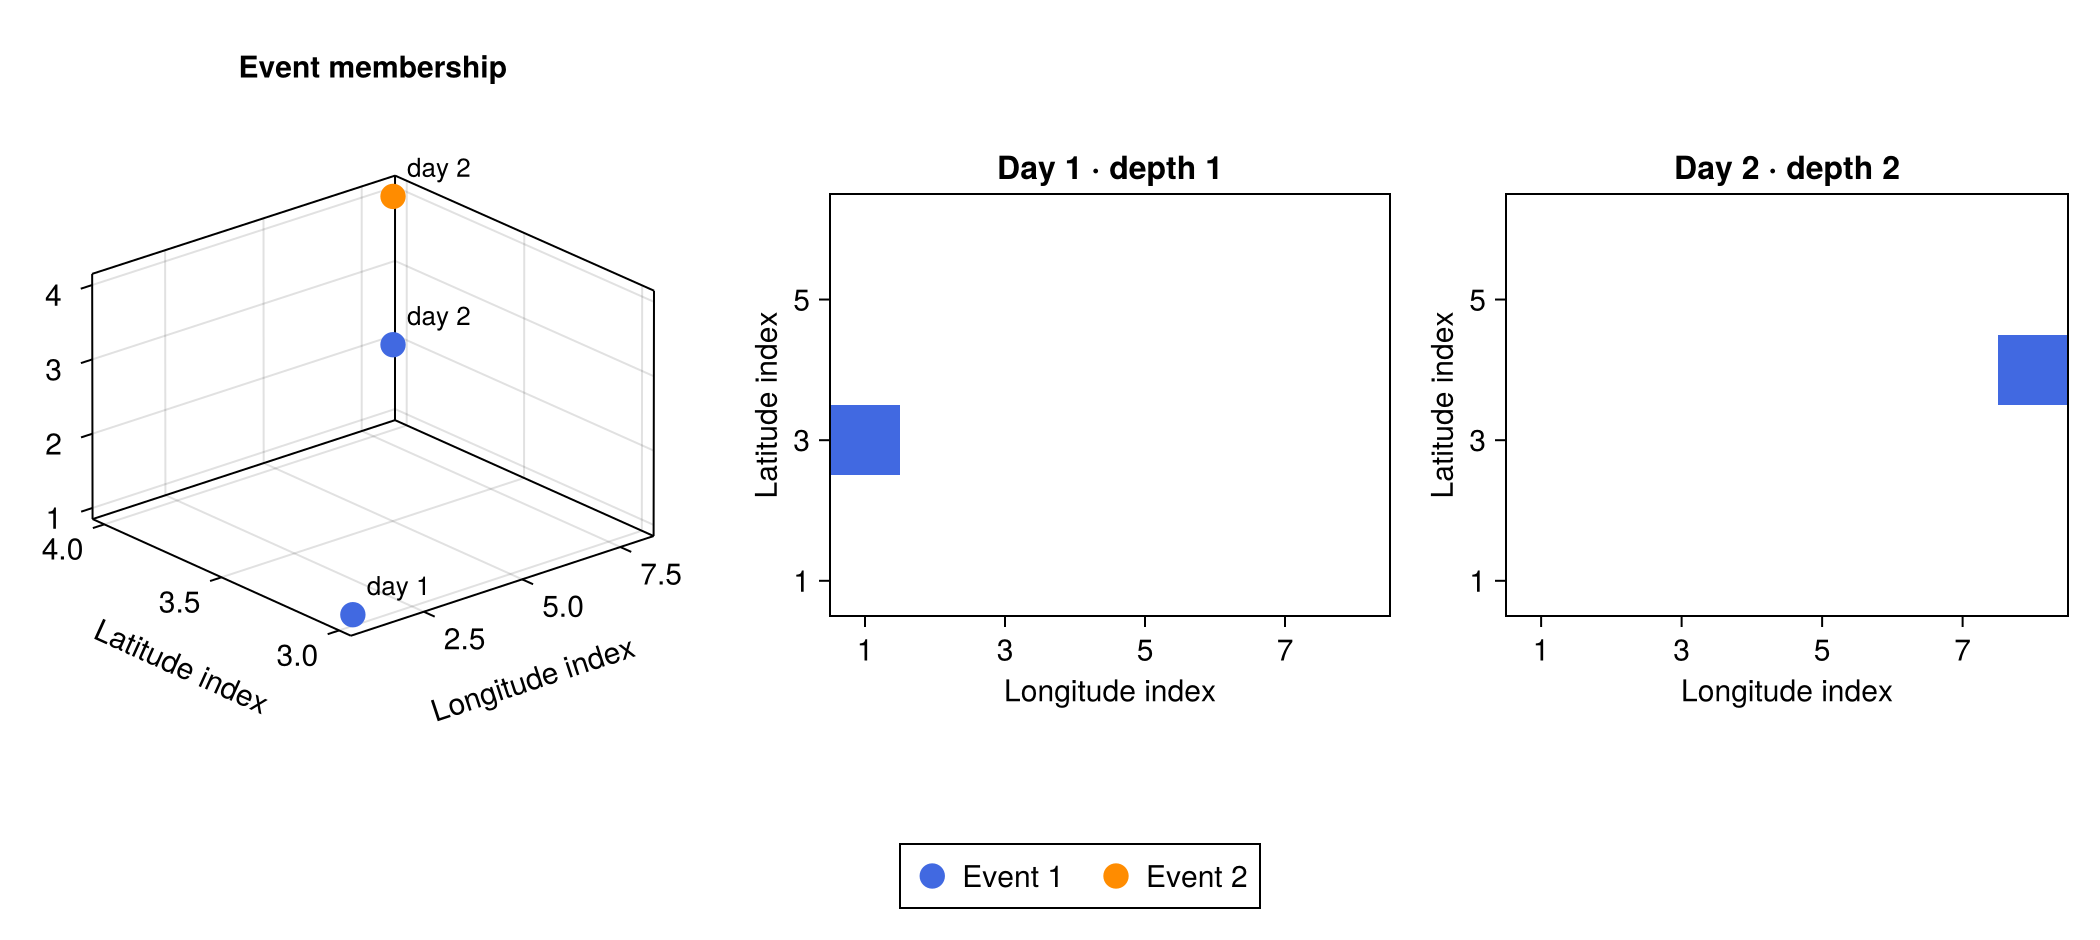

In [2]:
mask=falses(8,6,4,4)
mask[1,3,1,1]=true # A
mask[8,4,2,2]=true # B
mask[8,4,4,2]=true # C
tracks,info=track_mhw_4d_lonlat(mask;min_duration=1)
@test length(tracks)==2
lab=labels(tracks,size(mask)); coords=findall(mask)
println(info)
fig=Figure(size=(1050,470))
ax=Axis3(fig[1,1],title="Event membership",
    xlabel="Longitude index",ylabel="Latitude index",zlabel="Depth index")
for event_id in 1:length(tracks)
    pts=filter(p->lab[p]==event_id,coords)
    scatter!(ax,[p[1] for p in pts],[p[2] for p in pts],[p[3] for p in pts];
        color=EVENT_COLORS[event_id+1],markersize=18,label="Event $event_id")
    text!(ax,[Point3f(p[1],p[2],p[3]) for p in pts];text=["day $(p[4])" for p in pts],offset=(7,7),fontsize=13)
end
Legend(fig[2,1:3],ax;orientation=:horizontal)
label_panel(fig[1,2],lab[:,:,1,1];title="Day 1 · depth 1",maxlabel=2)
label_panel(fig[1,3],lab[:,:,2,2];title="Day 2 · depth 2",maxlabel=2)
emit_figure(fig,"03_regular_4d_connections")

## Synthetic MATLAB references: full event-field validation
Compare day, idx4, nvoxels, and full event partitions rather than counts alone. Inputs and reference outputs come from the original MATLAB function.

Test Summary:              | Pass  

Total  Time
Regular 4D MATLAB fixtures |   16     16  0.7s


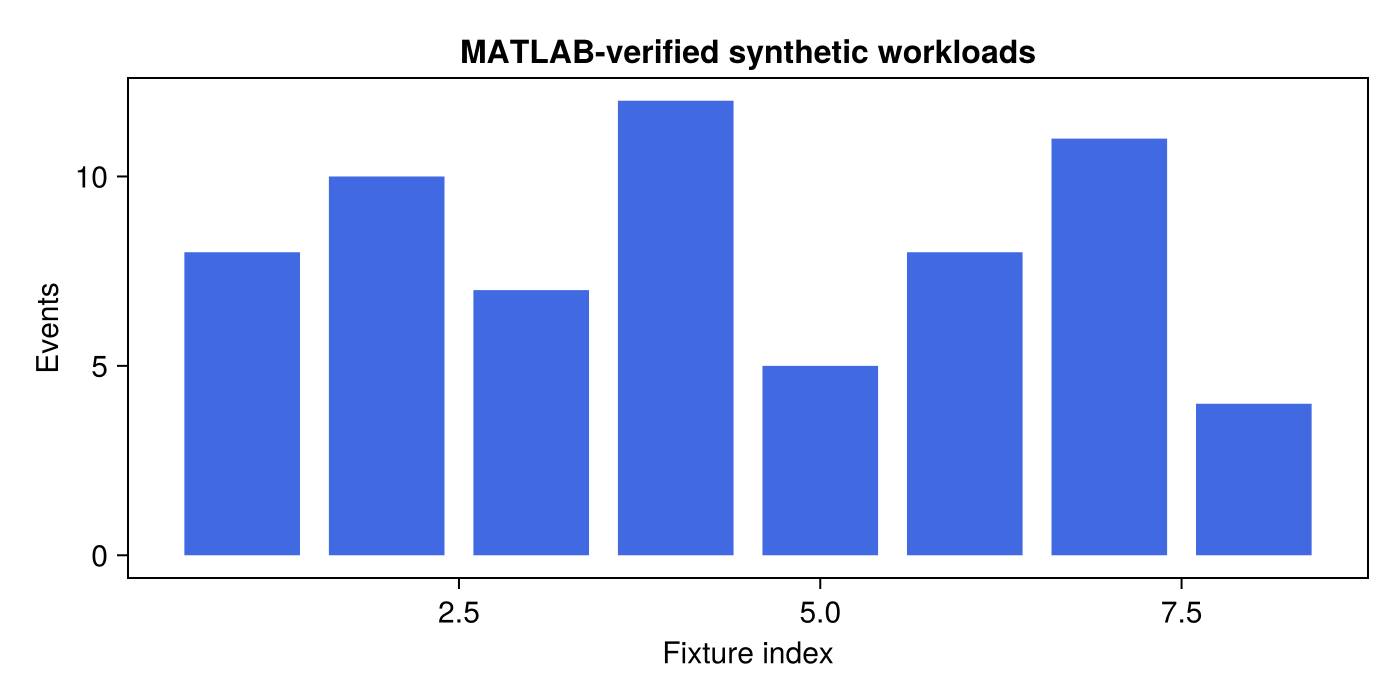

In [3]:
f=matread(joinpath(ROOT,"test","fixtures","lonlat4d.mat"))
counts=Int[]
@testset "Regular 4D MATLAB fixtures" begin
    for i in eachindex(f["masks"])
        actual,details=track_mhw_4d_lonlat(f["masks"][i];min_duration=1)
        expected=indexed_from_mat(f["tracks"][i],4)
        @test strict_indexed_equal(actual,expected)
        @test partition_equal(actual,expected)
        push!(counts,length(actual))
    end
end
fig=Figure(size=(700,350))
ax=Axis(fig[1,1],title="MATLAB-verified synthetic workloads",xlabel="Fixture index",ylabel="Events")
barplot!(ax,1:length(counts),counts;color=:royalblue)
emit_figure(fig,"03_regular_4d_fixture_counts")

## Mapping local time to global day labels
Connectivity still follows local time positions. Global days need not be consecutive, and repeated output days are merged. `time` does not automatically stitch events across files.

In [4]:
mapped,mapped_info=track_mhw_4d_lonlat(f["masks"][1];min_duration=1,
    time=vec(f["time"]),mask_size=Tuple(Int.(vec(f["global_size"]))),add_idx5_alias=true)
@test strict_indexed_equal(mapped,indexed_from_mat(f["mapped"],4))
println("Local-to-global time: ",vec(f["time"]))
println("First mapped event days: ",isempty(mapped) ? Int[] : mapped[1].day)

Local-to-global time: 

[8.0, 2.0, 2.0, 10.0, 5.0, 11.0, 6.0]
First mapped event days: Int32[8]
